# CIVE 202 Project 3 Final Analysis

This notebook analyzes:
- **NHTS**: transportation usage characteristics.
- **NGSIM**: microscopic driving behavior.

Required deliverables included below:
1. Bar chart (category comparison)
2. Histogram (distribution)
3. Boxplot (distribution by category)
4. Two time-series plots (driving behavior)
5. Intelligent Driver Model (IDM) simulation study


In [22]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Apply plotting theme
sns.set_theme(style="whitegrid")

#Load NHTS and NGSIM datasets
nhts = pd.read_csv("../NHTS.csv")
ngsim = pd.read_csv("../NGSIM.csv")

#Convert vehicle age to numeric values and fill non valid entries with NaN
nhts["vehicle_age"] = pd.to_numeric(nhts["vehicle_age"], errors="coerce")

#Preview available fields and trajectory count
print("NHTS Columns:", nhts.columns)
print("NGSIM Columns:", ngsim.columns)
print("Trajectory count:", ngsim["trajectory_number"].nunique())

NHTS Columns: Index(['household_id', 'census_division', 'census_region', 'driver_count',
       'household_income', 'household_size', 'household_workers', 'home_type',
       'household_location', 'number_adults_household',
       'vehicles_per_household', 'travel_date', 'travel_day', 'urban',
       'vehicle_type', 'hybrid', 'make', 'vehicle_age', 'vehicle_commercial',
       'vehicle_delivery', 'vehicle_rideshare', 'fuel_type', 'vehicle_year'],
      dtype='object')
NGSIM Columns: Index(['Time', 'leader_position(m)', 'follower_position(m)',
       'leader_speed(m/s)', 'follower_speed(m/s)', 'leader_acc(m/s^2)',
       'follower_acc(m/s^2)', 'trajectory_number'],
      dtype='object')
Trajectory count: 16


In [23]:
#1. Select a trajectory number 1 from the NGSIM dataset for analysis
trajectory_id1 = int(input("Enter the first trajectory number for analysis 1, (1-16) FOR THIS REPORT, 12: "))
#2. Select a trajectory number 2 from the NGSIM dataset for analysis
trajectory_id2 = int(input("Enter the second trajectory number for analysis 2, (1-16) FOR THIS REPORT, 13: "))

## 1) Bar Chart: NHTS Trips by Day of Week

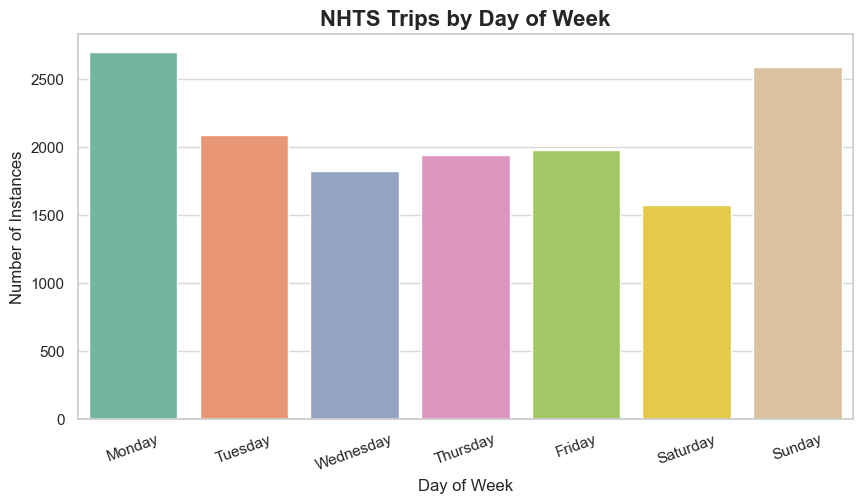

In [24]:
#Define weekday order for plotting
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

#Count travel records by day and preserve weekday order
day_counts = nhts["travel_day"].value_counts().reindex(day_order).fillna(0)

#Create bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=day_counts.index, y=day_counts.values, hue=day_counts.index, palette="Set2")

#Add labels and title
plt.title("NHTS Trips by Day of Week", fontsize=16, fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Number of Instances")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.75)

plt.show()

## 2) Histogram: NHTS Vehicle Age Distribution

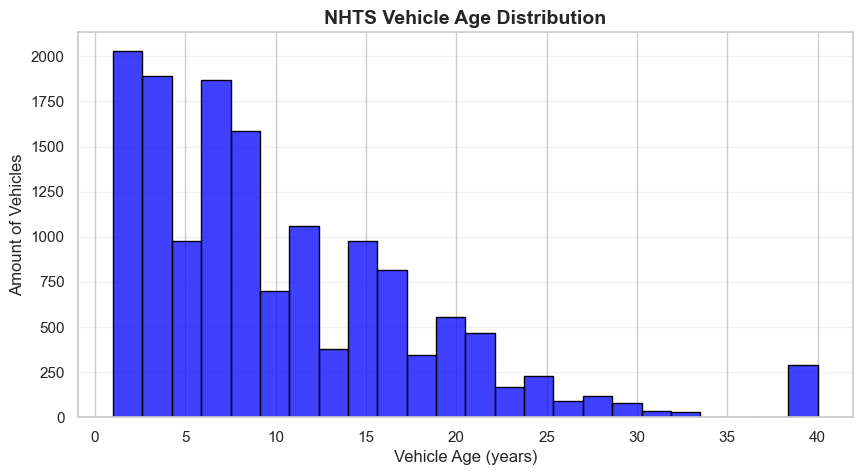

In [25]:
#Plot histogram of vehicle age values
plt.figure(figsize=(10, 5))
sns.histplot(nhts["vehicle_age"].dropna(), bins=24, color="blue", edgecolor="black")

#Add labels and title
plt.title("NHTS Vehicle Age Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Vehicle Age (years)")
plt.ylabel("Amount of Vehicles")
plt.grid(axis="y", alpha=0.25)


plt.show()

## 3) Boxplot: Vehicle Age by Census Region

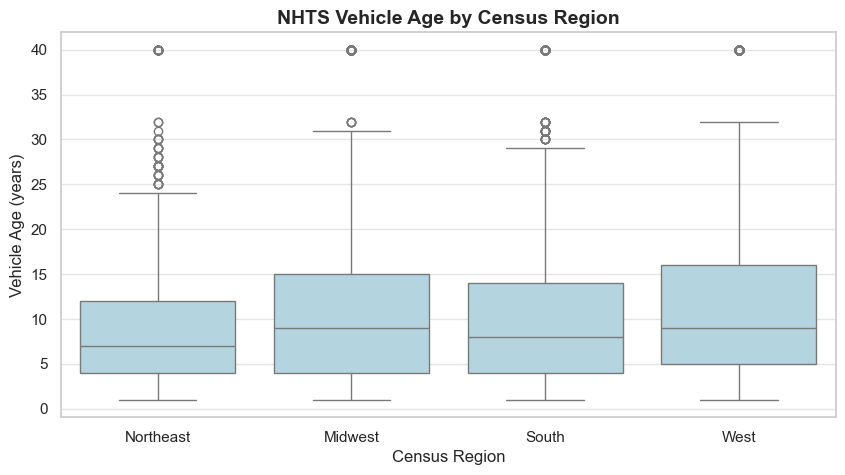

In [26]:
#Set region display order
region_order = ["Northeast", "Midwest", "South", "West"]

#Create boxplot by census region
plt.figure(figsize=(10, 5))
sns.boxplot(data=nhts, x="census_region", y="vehicle_age", order=region_order, color="lightblue")

#Add labels and title
plt.title("NHTS Vehicle Age by Census Region", fontsize=14, fontweight="bold")
plt.xlabel("Census Region")
plt.ylabel("Vehicle Age (years)")
plt.grid(axis="y", alpha=0.50)

plt.show()

## 4) Time-Series Plot: Leader vs Follower Speed

We select one NGSIM trajectory and compare leader/follower speed over time.


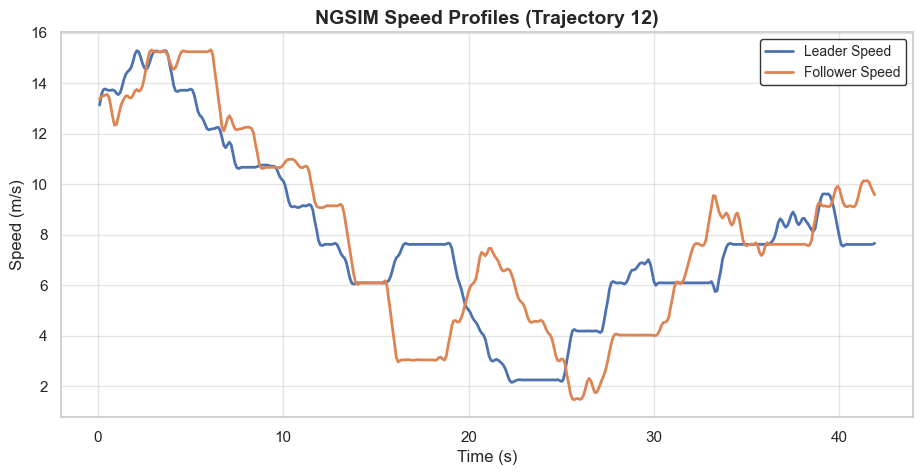

In [27]:
#Select first NGSIM trajectory for speed comparison
traj = ngsim.loc[ngsim["trajectory_number"] == trajectory_id1].copy().sort_values("Time")

#Plot leader and follower speed over time
plt.figure(figsize=(11, 5))
plt.plot(traj["Time"], traj["leader_speed(m/s)"], label="Leader Speed", linewidth=2)
plt.plot(traj["Time"], traj["follower_speed(m/s)"], label="Follower Speed", linewidth=2)

#Add labels, title, and legend
plt.title(f"NGSIM Speed Profiles (Trajectory {trajectory_id1})", fontsize=14, fontweight="bold")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.legend(fontsize=10, frameon=True, edgecolor="black")
plt.grid(alpha=0.5)

plt.show()

## 4) Time-Series Plot: Leader vs Follower Speed PT2

We select a different NGSIM trajectory and can compare between the two chosen trajectories.

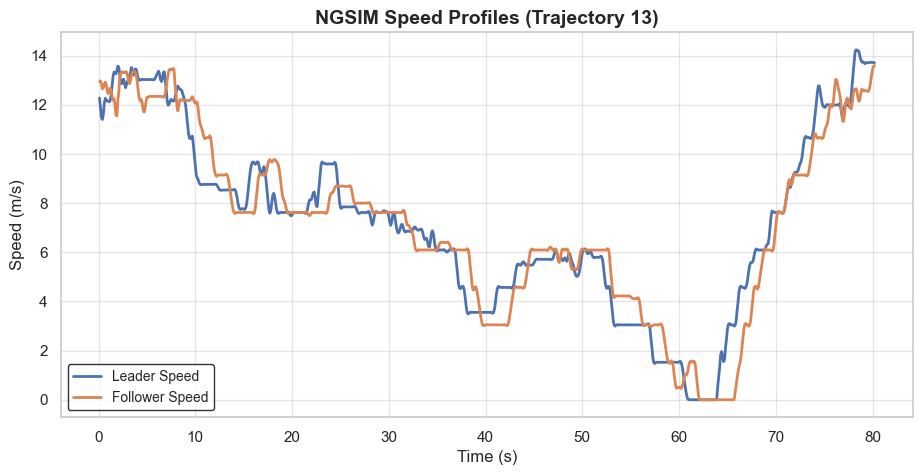

In [28]:
#Select second NGSIM trajectory for comparison
trajectory_id2 = 13
traj = ngsim.loc[ngsim["trajectory_number"] == trajectory_id2].copy().sort_values("Time")

#Plot leader and follower speed over time
plt.figure(figsize=(11, 5))
plt.plot(traj["Time"], traj["leader_speed(m/s)"], label="Leader Speed", linewidth=2)
plt.plot(traj["Time"], traj["follower_speed(m/s)"], label="Follower Speed", linewidth=2)

#Add labels, title, and legend
plt.title(f"NGSIM Speed Profiles (Trajectory {trajectory_id2})", fontsize=14, fontweight="bold")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.legend(fontsize=10, frameon=True, edgecolor="black")
plt.grid(alpha=0.5)

plt.show()

## 5) Customized Time-Series Plot: Space Headway and Relative Speed

This plot demonstrates custom styling with dual axes, line colors, and linestyle changes.

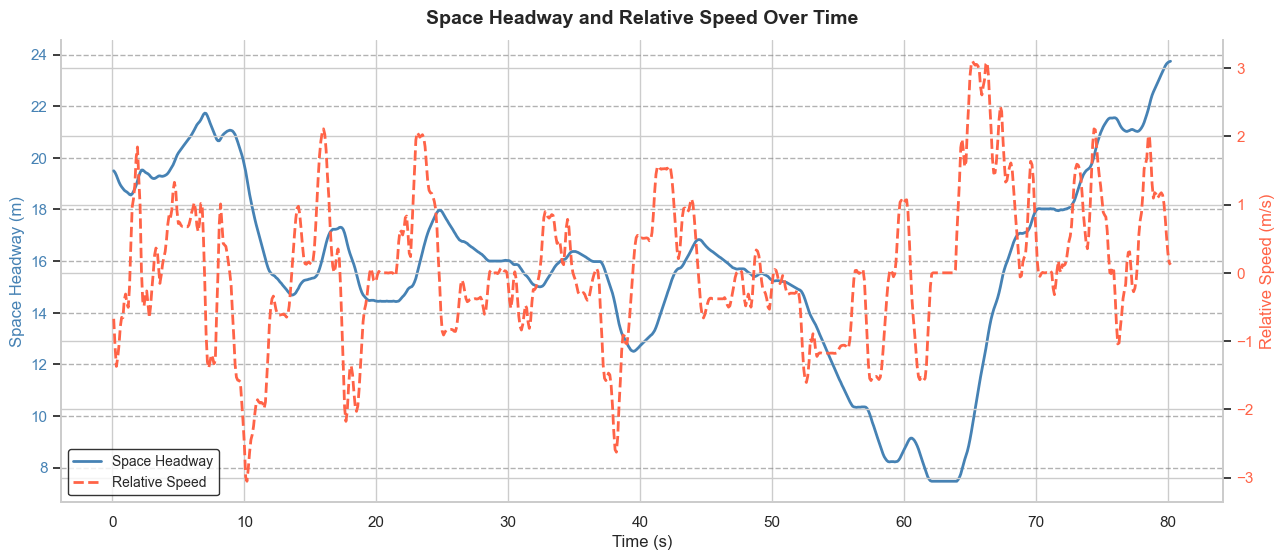

In [29]:
#Compute derived driving behavior variables
traj["space_headway(m)"] = traj["leader_position(m)"] - traj["follower_position(m)"]
traj["relative_speed(m/s)"] = traj["leader_speed(m/s)"] - traj["follower_speed(m/s)"]

#Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor("white")
ax1.set_facecolor("white")

#Plot space headway on left axis
color_left = "steelblue"
ax1.plot(traj["Time"], traj["space_headway(m)"], color=color_left, linewidth=2, label="Space Headway")
ax1.set_xlabel("Time (s)", fontsize=12)
ax1.set_ylabel("Space Headway (m)", fontsize=12, color=color_left)
ax1.tick_params(axis="y", labelcolor=color_left)
ax1.tick_params(axis="x")
ax1.grid(axis="y", linestyle="--", alpha=0.6, color="gray")
ax1.spines["top"].set_visible(False)

#Create secondary axis and plot relative speed
color_right = "tomato"
ax2 = ax1.twinx()
ax2.plot(traj["Time"], traj["relative_speed(m/s)"], color=color_right, linewidth=2, linestyle="--", label="Relative Speed")
ax2.set_ylabel("Relative Speed (m/s)", fontsize=12, color=color_right)
ax2.tick_params(axis="y", labelcolor=color_right)
ax2.spines["top"].set_visible(False)
ax2.set_facecolor("white")

#Merge legends from both axes into one legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc="lower left", fontsize=10, frameon=True, edgecolor="black", facecolor="white")

#Finalize title and render plot
ax1.set_title("Space Headway and Relative Speed Over Time", fontsize=14, fontweight="bold", pad=12)
plt.show()

## 6) Intelligent Driver Model (IDM) Simulation Study

The model simulates follower speed/position using observed leader behavior. We then compare observed vs simulated trajectories.

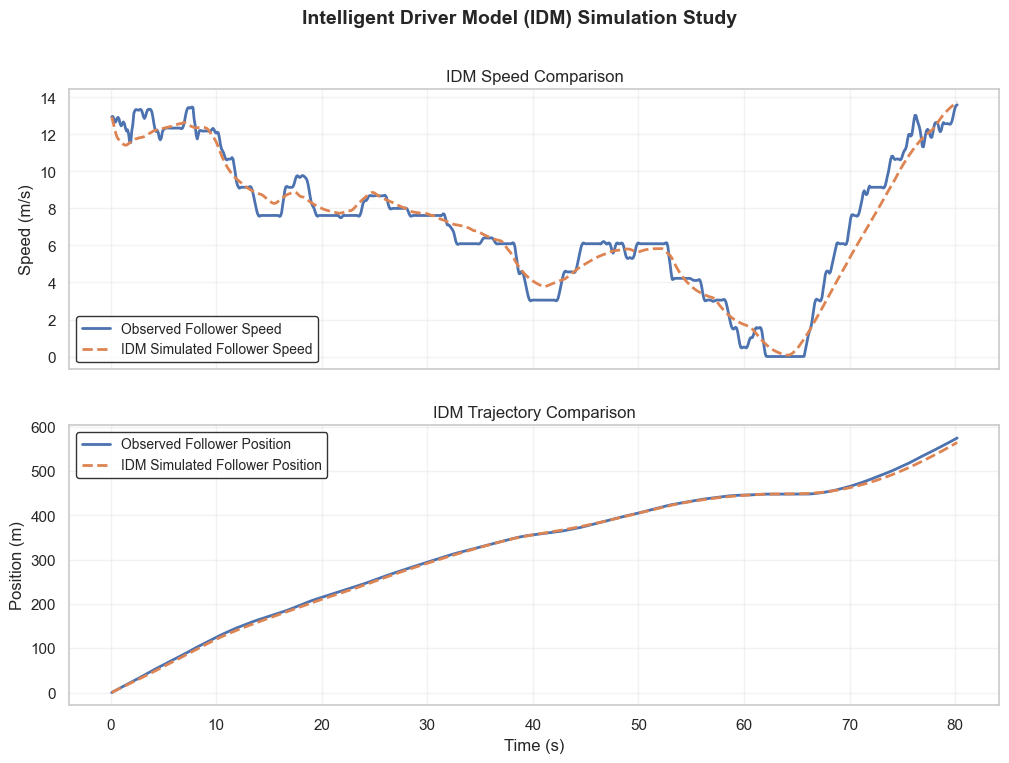

In [30]:
#Set IDM parameters for moderate driving behavior  
#(THIS IS THE INFORMATION YOU CAN CHANGE TO EXPLORE DIFFERENT DRIVING STYLES)

a_max = 1.2 #Maximum acceleration (m/s^2)
b = 1.8 #Comfortable deceleration (m/s^2)
delta = 4 #Acceleration exponent
t_headway = 1.5 #Desired time headway (s)
s0 = 2.0 #Minimum spacing (m)
v0 = 30.0 #Desired speed (m/s)
vehicle_length = 5.0 #Average vehicle length (m)

#Get time step and number of simulation points
dt = float(np.median(np.diff(traj["Time"])))
n = len(traj)

#Initialize simulation arrays for position, speed, and acceleration
x_sim = np.zeros(n) 
v_sim = np.zeros(n)
a_sim = np.zeros(n)

#Set follower initial state from observed trajectory
x_sim[0] = traj["follower_position(m)"].iloc[0] #Initialize position from observed data
v_sim[0] = traj["follower_speed(m/s)"].iloc[0] #Initialize speed from observed data

#Extract leader trajectories as NumPy arrays
x_lead = traj["leader_position(m)"].to_numpy() #Extract leader position as NumPy array
v_lead = traj["leader_speed(m/s)"].to_numpy() #Extract leader speed as NumPy array

#Run IDM simulation forward in time
for i in range(n - 1):
    #Compute current gap and relative speed
    gap = max(x_lead[i] - x_sim[i] - vehicle_length, 0.1)
    delta_v = v_sim[i] - v_lead[i]

    #Compute desired dynamic spacing term
    s_star = s0 + max(0.0, v_sim[i] * t_headway + (v_sim[i] * delta_v) / (2 * np.sqrt(a_max * b)))

    #Compute IDM acceleration
    acc = a_max * (1 - (v_sim[i] / v0) ** delta - (s_star / gap) ** 2)
    a_sim[i] = acc

    #Update speed and position to next time step
    v_sim[i + 1] = max(v_sim[i] + acc * dt, 0.0)
    x_sim[i + 1] = x_sim[i] + v_sim[i] * dt + 0.5 * acc * dt**2


#Calculate fit metrics against observed follower trajectory
speed_rmse = np.sqrt(np.mean((v_sim - traj["follower_speed(m/s)"].to_numpy()) ** 2))
pos_rmse = np.sqrt(np.mean((x_sim - traj["follower_position(m)"].to_numpy()) ** 2))

#Create side-by-side validation plots for speed and position
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)



#Top panel: observed vs simulated speed
axes[0].plot(traj["Time"], traj["follower_speed(m/s)"], label="Observed Follower Speed", linewidth=2)
axes[0].plot(traj["Time"], v_sim, "--", label="IDM Simulated Follower Speed", linewidth=2)

#Add labels, title, and legend
axes[0].set_ylabel("Speed (m/s)")
axes[0].set_title("IDM Speed Comparison")
axes[0].legend(fontsize=10, frameon=True, edgecolor="black")
axes[0].grid(alpha=0.25)



#Bottom panel: observed vs simulated position
axes[1].plot(traj["Time"], traj["follower_position(m)"], label="Observed Follower Position", linewidth=2)
axes[1].plot(traj["Time"], x_sim, "--", label="IDM Simulated Follower Position", linewidth=2)

#Add labels, title, and legend
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Position (m)")
axes[1].set_title("IDM Trajectory Comparison")
axes[1].legend(fontsize=10, frameon=True, edgecolor="black")
axes[1].grid(alpha=0.25)



#Add overall figure title and show result
fig.suptitle("Intelligent Driver Model (IDM) Simulation Study", fontsize=14, fontweight="bold")
plt.show()

## 7) Model Performance (Root Mean Square Error)

This short summary reports IDM fit quality for the chosen trajectory. Lower RMSE values indicate closer agreement between simulated and observed follower behavior.

In [31]:
#Print IDM performance summary
print(f"IDM speed RMSE: {speed_rmse:.3f} m/s")
print(f"IDM position RMSE: {pos_rmse:.3f} m")

IDM speed RMSE: 0.728 m/s
IDM position RMSE: 4.081 m
